In [1]:
import json
import os
import time
from pathlib import Path

import numpy as np
import torch
from models.qmc_base import QMCLVM
from models.sampling import gen_fib_basis, gen_korobov_basis
from models.utils import get_decoder_arch
# from plotting.visualize import qmc_train_plot #, model_grid_plot
# from plotting.visualize_3d import model_grid_plot

from train.losses import binary_evidence, binary_lp
from train.train import test_epoch

from gily_code import eval_utils as eu

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch.nn.functional as F

In [2]:
import numpy as np
import fastplotlib as fpl
import h5py

Unable to find extension: VK_EXT_physical_device_drm
No windowing system present. Using surfaceless platform
No config found!
No config found!
Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA A100-SXM4-40GB,DiscreteGPU,Vulkan,560.35.05
❌,NVIDIA A100-SXM4-40GB/PCIe/SSE2,Unknown,OpenGL,3.3.0 NVIDIA 560.35.05


Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048


In [3]:
DATA_ROOT = {
    1: ["/mnt/home/kkolar/data/gerbils/235/"],
}
FAMILIES = [1]
CKPT_DIR = "/mnt/home/kkolar/data/gerbils/uncond_all_2D/"

OUT_DIR_OVERRIDE = None  # leave None to write under CKPT_DIR/eval_<run_id>

BATCH_SIZE = 256
NUM_WORKERS = 0
SPECS_PER_FILE = 100
TEST_SIZE = 0.20
SPLIT_SEED = 92
LATENT_DIM = 2
M_FIB = 15
# Korobov 3D
N_LATENT_POINTS = 1021  # or 2039, 4093
a_korobov = 76

In [4]:
def rebuild_unconditional_model(device: torch.device) -> QMCLVM:
    decoder = get_decoder_arch(dataset_name="gerbil_ava", latent_dim=LATENT_DIM, arch="qmc")
    return QMCLVM(latent_dim=LATENT_DIM, device=device, decoder=decoder)

torch.manual_seed(92)
np.random.seed(92)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(92)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# 1) Data
train_loader, test_loader, (train_fns, test_fns) = eu.build_plain_loaders(
    DATA_ROOT,
    FAMILIES,
    specs_per_file=SPECS_PER_FILE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    test_size=TEST_SIZE,
    split_seed=SPLIT_SEED,
)
print("[data] train batches:", len(train_loader), "test batches:", len(test_loader))

[device] cuda
[load] family1


checking /mnt/home/kkolar/data/gerbils/235/processed-data/family1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 189.31it/s]

[data] train batches: 115 test batches: 29


In [5]:
# 2) Model + checkpoint
ckpt_path = eu.latest_checkpoint(CKPT_DIR)
print("[ckpt] loading", ckpt_path)
model = rebuild_unconditional_model(device)
train_losses, epoch = eu.load_model_weights(model, ckpt_path, device)

# latent_grid = gen_korobov_basis(a=a_korobov,num_dims=LATENT_DIM,num_points=N_LATENT_POINTS) 
latent_grid = gen_fib_basis(m=M_FIB)

[ckpt] loading /mnt/home/kkolar/data/gerbils/uncond_all_2D/final_20251130_192820.pt


In [6]:
img = model.forward(torch.Tensor([0.5, 0.5]).to("cuda"), random=False, mod=False).detach().cpu().numpy()

def binary_lp(samples,data,importance_weights=[]):

    ## following the example of torch BCEloss, this clamps the log terms at -100
    ## to prevent bad gradients
    ## Samples should be KSamples x Channels x H x W
    try:
        K,C,H,W = samples.shape
        if len(importance_weights) == 0:
            importance_weights = torch.ones((1,K),device=samples.device,dtype=torch.float32)
        
        samples = torch.clamp(samples,min=1e-6,max=1-1e-6)
        #samples[samples <= 1e-6] = samples[samples <= 1e-6] - samples[samples <= 1e-6] + 1e-6
        #samples[samples >= 1 - 1e-6] = samples[samples >= 1 - 1e-6] - samples[samples >= 1 - 1e-6] + 1 - 1e-6
        #samples = torch.clamp(samples,min=1e-6,max=1-1e-6)

        ## should this be log2....
        t1 = torch.einsum('bjdl,sjdl->bs',data,torch.log(samples))
        t2 = torch.einsum('bjdl,sjdl->bs',1-data,torch.log(1-samples))
        #if torch.any(t1 == )
        assert not torch.any(t1 == torch.nan)
        assert not (torch.any(t2 == torch.nan))
    
        ### returns: batch x n samples
        return (t1 + t2) +torch.log(importance_weights)
    except:
        print("shapes were probably weird: here's what they were:")
        print(f"samples: {samples.shape}")
        print(f"data: {data.shape}")
        assert False

from tqdm import tqdm

qlvm_lp = binary_lp

train_posterior = []
test_posterior = []

for batch, _ in tqdm(train_loader, total=len(train_loader)):
    batch = batch.to(model.device)
    train_posterior.append(
        model.posterior_probability(
            latent_grid.to("cuda"), batch, qlvm_lp
        ).detach().cpu().numpy()
    )

train_aggregated_posterior = np.nanmean(np.vstack(train_posterior),axis=0)

for batch,_ in tqdm(test_loader,total=len(test_loader)):
    batch = batch.to(model.device)
    test_posterior.append(model.posterior_probability(latent_grid.to("cuda"),batch,qlvm_lp).detach().cpu().numpy())

test_aggregated_posterior = np.nanmean(np.vstack(test_posterior),axis=0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:56<00:00,  1.94s/it]


In [7]:
train_aggregated_posterior.shape

(610,)

In [8]:
plot_lattice = (latent_grid % 1).detach().cpu().numpy()
plot_lattice

array([[0.        , 0.        ],
       [0.00163934, 0.6180328 ],
       [0.00327869, 0.23606563],
       ...,
       [0.99508196, 0.14590454],
       [0.9967213 , 0.76394653],
       [0.99836063, 0.381958  ]], shape=(610, 2), dtype=float32)

In [9]:
import pygfx
from itertools import product

In [10]:
recon_shape = model(torch.Tensor([0.5, 0.5]).to("cuda"), random=False, mod=False).detach().cpu().numpy().squeeze().shape

In [11]:
grid_x, grid_y = np.meshgrid(np.linspace(0, 1, num=10), np.linspace(0, 1, num=10))
grid = np.column_stack([grid_x, grid_y])

RFBOutputContext()

Max vertex attribute stride unknown. Assuming it is 2048
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:11<00:00, 34.14it/s]


JupyterRenderCanvas(css_height='700.0px', css_width='1000.0px')
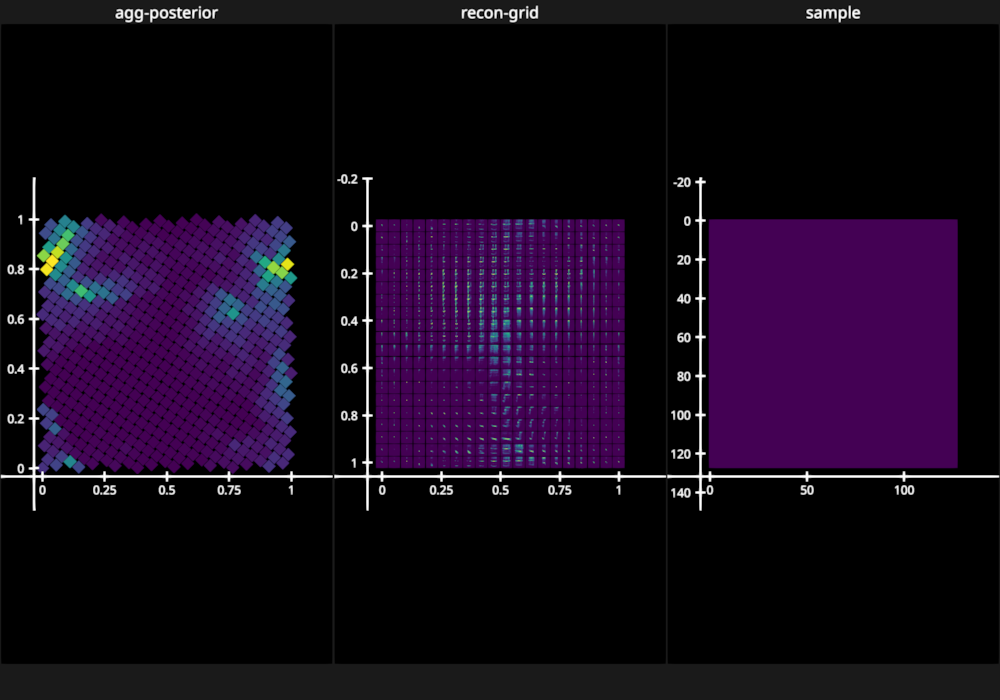

In [12]:
fig = fpl.Figure(shape=(1, 3), names=["agg-posterior", "recon-grid", "sample"], size=(1000, 700))

x_density = np.diff(np.unique(np.sort(plot_lattice[:, 0]))).mean()
y_density = np.diff(np.unique(np.sort(plot_lattice[:, 1]))).mean()
density = np.mean([x_density, y_density])

scatter_posterior = fig["agg-posterior"].add_scatter(
    plot_lattice, 
    cmap="viridis", 
    cmap_transform=train_aggregated_posterior, 
    sizes=density * 32, 
    size_space="model",
    edge_width=0.001, 
    edge_colors=(0, 0, 0, 0),
    uniform_edge_color=False,
    markers="D",
    # metadata=train_aggregated_posterior,
)

image = fig["sample"].add_image(np.zeros(recon_shape), cmap="viridis", vmin=0, vmax=1)

def update_sample(ev: pygfx.PointerEvent):
    latent_pos_agg = fig["agg-posterior"].map_screen_to_world(ev)
    latent_pos_grid = fig["recon-grid"].map_screen_to_world(ev)
    
    if latent_pos_agg is not None:
        latent_pos = latent_pos_agg[:-1].astype(np.float32)
    elif latent_pos_grid is not None:
        latent_pos = latent_pos_grid[:-1].astype(np.float32)
    else:
        return    
        
    # set sample
    image.data = model(torch.from_numpy(latent_pos).to("cuda"), random=False, mod=False).detach().cpu().numpy().squeeze()

scatter_posterior.add_event_handler(update_sample, "pointer_move")
fig["recon-grid"].renderer.add_event_handler(update_sample, "pointer_move")

# sample grid
# we will display 10 rows and 10 columns
n_rows = 20
n_cols = 20
rows = np.linspace(0, 1, num=n_rows)
columns = np.linspace(0, 1, num=n_cols)

# spacing between each image
spacing = 1

index = 0
for i, j in tqdm(product(rows, columns), total=(n_rows * n_cols)):
        latent_pos = torch.Tensor([i, j])
        img = model(latent_pos.to("cuda"), random=False, mod=False).detach().cpu().numpy().squeeze()
        
        # offset is x, y, z position
        # offset = (j * (columns/ + spacing * j, i * img.shape[0] + spacing * i, 0)
        # # offset = (j * img.shape[1] + spacing * j, i * img.shape[0] + spacing * i, 0)
        img_graphic = fig["recon-grid"].add_image(img, cmap="viridis", offset=(i - (rows[1] / 2) , j - (columns[1] / 2), 0))
        
        img_graphic.world_object.world.scale_x = 1 / img.shape[0] / n_cols
        img_graphic.world_object.world.scale_y = 1 / img.shape[1] / n_rows
        index += 1


fig.show()

In [15]:
fig["recon-grid"].camera.local.scale_y *= -1
fig["sample"].camera.local.scale_y *= -1

fig["recon-grid"].tooltip.background_color = (0, 0, 0, 0)
fig["recon-grid"].tooltip.outline_color = (0, 0, 0, 0)
fig["recon-grid"].tooltip.text_color = (0, 0, 0, 0)

In [14]:
cursor = fpl.Cursor()

for sn in ["agg-posterior", "recon-grid"]:
    cursor.add_subplot(fig[sn])